In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("heart (1).csv") 
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [3]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


###  1.Train a Decision Tree Classifier and visualize the tree.

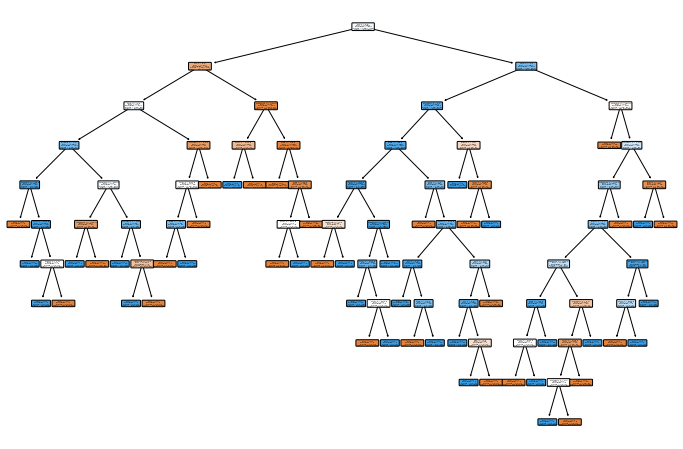

Accuracy on test data: 0.99


In [6]:
# Split the dataset into features (X) and target (y)
X = df.drop('target', axis=1)  # Drop the target column for features
y = df['target']  # Target column

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Visualize 
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=['No Disease', 'Disease'], rounded=True)
plt.show()

# Evaluate the model
accuracy = clf.score(X_test, y_test)
print(f"Accuracy on test data: {accuracy:.2f}")

###  2.Analyze overfitting and control tree depth.

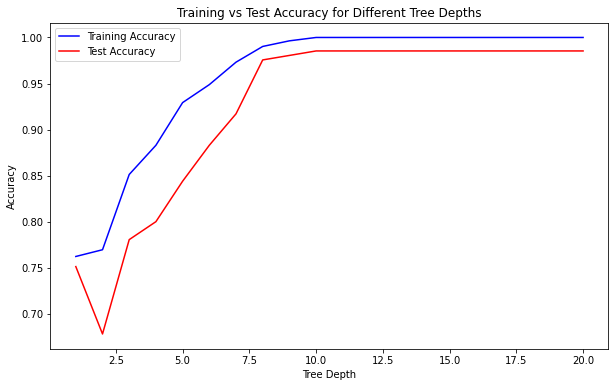

In [8]:
train_accuracies = []
test_accuracies = []

for depth in range(1, 21):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    
    train_accuracy = clf.score(X_train, y_train)
    test_accuracy = clf.score(X_test, y_test)
    
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), train_accuracies, label='Training Accuracy', color='blue')
plt.plot(range(1, 21), test_accuracies, label='Test Accuracy', color='red')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy for Different Tree Depths')
plt.legend()
plt.show()

### 3.Train a Random Forest and compare accuracy.

In [20]:
# Train Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
dt_train_accuracy = dt_clf.score(X_train, y_train)
dt_test_accuracy = dt_clf.score(X_test, y_test)

# Train Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
rf_train_accuracy = rf_clf.score(X_train, y_train)
rf_test_accuracy = rf_clf.score(X_test, y_test)

# Print accuracies for comparison
print(f"Decision Tree Accuracy on Training Set: {dt_train_accuracy:.2f}")
print(f"Decision Tree Accuracy on Test Set: {dt_test_accuracy:.2f}")
print(f"Random Forest Accuracy on Training Set: {rf_train_accuracy:.2f}")
print(f"Random Forest Accuracy on Test Set: {rf_test_accuracy:.2f}")

Decision Tree Accuracy on Training Set: 1.00
Decision Tree Accuracy on Test Set: 0.99
Random Forest Accuracy on Training Set: 1.00
Random Forest Accuracy on Test Set: 0.99


###  4.Interpret feature importances.

     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444


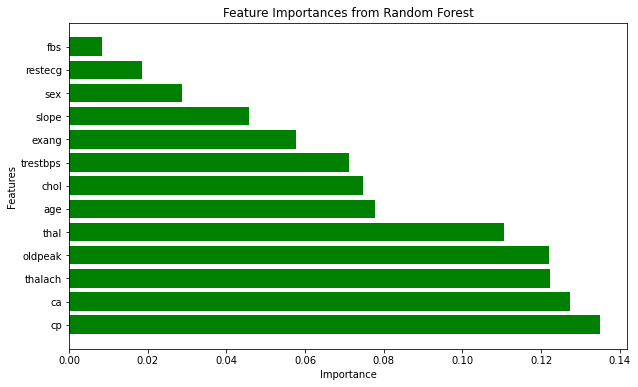

In [7]:
# Extract feature importances from the trained Random Forest model
importances = rf_clf.feature_importances_

# Create a DataFrame to organize the feature importances
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the feature importances
print(feature_importance_df)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='green')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importances from Random Forest')
plt.show()


### 5.Evaluate using cross-validation.

In [19]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_cv_scores = cross_val_score(dt_clf, X, y, cv=5, scoring='accuracy')  # 5-fold cross-validation

# Cross-validation with Random Forest
rf_clf = RandomForestClassifier(random_state=42)
rf_cv_scores = cross_val_score(rf_clf, X, y, cv=5, scoring='accuracy')  # 5-fold cross-validation

# Output the results
print(f"Decision Tree Cross-Validation Accuracy: {np.mean(dt_cv_scores):.2f} ± {np.std(dt_cv_scores):.2f}")
print(f"Random Forest Cross-Validation Accuracy: {np.mean(rf_cv_scores):.2f} ± {np.std(rf_cv_scores):.2f}")

Decision Tree Cross-Validation Accuracy: 1.00 ± 0.00
Random Forest Cross-Validation Accuracy: 1.00 ± 0.01
